In [1]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 0: Install & Imports (PBT-V for Vision)
# ════════════════════════════════════════════════════════════════════════════════════
!pip install -q transformers accelerate datasets scikit-learn matplotlib seaborn torch torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import gc

from transformers import AutoImageProcessor, AutoModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

# ป้องกัน GPU Memory เต็ม
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[System] Libraries loaded successfully. Computing device: {device}")

[System] Libraries loaded successfully. Computing device: cuda


In [2]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 1: PBT-V Architecture & Load Base Model (DINOv2)
# ════════════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 90)
print('  🧠 Initialize PBT-V Architecture (DINOv2-Small Backbone)')
print('=' * 90)

# ─── 1. Load Base Vision Model ───
model_id = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_id)
base_model = AutoModel.from_pretrained(model_id).to(device)
base_model.eval()

# พารามิเตอร์โครงสร้างของ DINOv2-Small
D_MODEL = 384
N_LAYERS = 12

# ─── 2. PBT-V Hybrid Adapter Architecture ───
class PBTVisionAdapter(nn.Module):
    def __init__(self, d_model=D_MODEL, n_layers=N_LAYERS, num_classes=2):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers

        # Module E (Prediction Error): ค่าความเชื่อมั่นราย Layer
        self.module_e = nn.Parameter(torch.ones(n_layers))

        # Module V (Valence Probes): แปลง Prediction Error เป็นอารมณ์ 3 มิติ
        self.valence_probes = nn.ModuleList([
            nn.Linear(d_model, 3) for _ in range(n_layers)
        ])

        # Module M (Memory Accumulator): อัตราการสลายตัว (Decay rates / Gamma)
        self.module_m_gamma = nn.Parameter(torch.tensor([0.05, 0.10, 0.15]))

        # Module R (Reflex/Classifier): โครงข่ายสำหรับประมวลผลการตอบสนองขั้นสุดท้าย
        in_features = d_model + (n_layers * 3) + 3
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        # หน่วยความจำภายในสำหรับการประมวลผล Video Stream
        self.prev_h = None
        self.v_acc = None

    def reset_state(self):
        """ล้างสถานะความทรงจำเมื่อเริ่มต้นการทดลองหรือชุดวิดีโอใหม่"""
        self.prev_h = None
        self.v_acc = None

    def forward(self, h_current):
        """
        h_current: Hidden states ของเฟรมปัจจุบันที่สกัดจากโมเดลหลัก [Batch, Layers, Dim]
        """
        B, L, D = h_current.shape

        # การเตรียมสถานะเริ่มต้นสำหรับเฟรมแรก
        if self.prev_h is None or self.prev_h.shape[0] != B:
            self.prev_h = h_current.detach()
            self.v_acc = torch.zeros(B, 3, device=h_current.device)

        # 1. Module E: คำนวณ Temporal Prediction Error (ε)
        epsilon_list = []
        for l in range(self.n_layers):
            # วัดความแตกต่างเชิงเรขาคณิตจากเฟรมก่อนหน้า
            eps = h_current[:, l, :] - self.prev_h[:, l, :]
            eps = eps * self.module_e[l]
            epsilon_list.append(eps)
        epsilon_stack = torch.stack(epsilon_list, dim=1) # [B, L, D]

        # 2. Module V: สกัดอารมณ์จากความคลาดเคลื่อน
        v_list = []
        for l in range(self.n_layers):
            v_l = self.valence_probes[l](epsilon_stack[:, l, :]) # [B, 3]
            v_list.append(v_l)
        v_feat = torch.stack(v_list, dim=1) # [B, L, 3]

        v_step = v_feat.mean(dim=1) # [B, 3]

        # 3. Module M: สะสมผลลัพธ์เชิงเวลา (Temporal Accumulation)
        gamma = torch.clamp(self.module_m_gamma, min=0.001, max=0.999)
        self.v_acc = v_step + (1 - gamma) * self.v_acc

        # 4. Module R: การตัดสินใจขั้นสุดท้าย
        h_last = h_current[:, -1, :] # ดึงข้อมูล Scene Context จาก Layer สุดท้าย
        v_feat_flat = v_feat.view(B, -1) # [B, L * 3]
        combined = torch.cat([h_last, v_feat_flat, self.v_acc], dim=1) # [B, D + (L*3) + 3]
        logits = self.classifier(combined)

        # บันทึกข้อมูลเพื่อใช้เป็นค่าคาดการณ์ในเฟรมถัดไป
        self.prev_h = h_current.detach()

        return logits, self.v_acc, v_feat

# Instantiate Adapter
adapter = PBTVisionAdapter().to(device)
print(f"[System] Model & PBT-V Adapter ready.")


  🧠 Initialize PBT-V Architecture (DINOv2-Small Backbone)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[System] Model & PBT-V Adapter ready.


In [3]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 2: Prepare Sequential Vision Dataset (Synthetic Video Stream)
# สร้างชุดข้อมูลภาพต่อเนื่องเพื่อจำลองสถานการณ์ปกติและสถานการณ์ฉุกเฉิน
# ════════════════════════════════════════════════════════════════════════════════════
import numpy as np
from PIL import Image, ImageDraw

print('\n' + '=' * 90)
print('  🎥 Generating Synthetic Video Sequences for PBT-V Testing')
print('=' * 90)

def generate_synthetic_video(sequence_type="safe", num_frames=10, img_size=224):
    """
    สร้างภาพจำลองการเคลื่อนที่ของหุ่นยนต์ (เฟรมต่อเฟรม)
    - safe: วัตถุเคลื่อนที่อย่างราบรื่น
    - unsafe: วัตถุปรากฏขึ้นกะทันหันหรือเกิดการชนในเฟรมที่ 5
    """
    frames = []
    # พื้นหลังสีเทาจำลองพื้นถนน
    bg_color = (120, 120, 120)

    for i in range(num_frames):
        img = Image.new('RGB', (img_size, img_size), color=bg_color)
        draw = ImageDraw.Draw(img)

        if sequence_type == "safe":
            # จำลองวัตถุเป้าหมายที่เคลื่อนที่อย่างสม่ำเสมอ
            x_pos = 20 + (i * 15)
            draw.rectangle([x_pos, 100, x_pos + 40, 140], fill=(0, 255, 0))

        elif sequence_type == "unsafe":
            if i < 5:
                # เฟรม 0-4: สถานการณ์ปกติ
                x_pos = 20 + (i * 15)
                draw.rectangle([x_pos, 100, x_pos + 40, 140], fill=(0, 255, 0))
            else:
                # เฟรม 5-9: เกิดการเปลี่ยนแปลงเรขาคณิตกะทันหัน (Anomaly/Collision)
                # จำลองสิ่งกีดขวางขนาดใหญ่สีแดงที่ปรากฏขึ้น
                draw.rectangle([50, 50, 180, 180], fill=(255, 0, 0))

        frames.append(img)
    return frames

# 1. สร้างชุดข้อมูล
safe_video = generate_synthetic_video(sequence_type="safe", num_frames=10)
unsafe_video = generate_synthetic_video(sequence_type="unsafe", num_frames=10)

# 2. ฟังก์ชันแปลงรูปภาพเป็น Tensor ผ่าน DINOv2 Processor
def process_video_frames(frames):
    processed = []
    for frame in frames:
        # processor จะคืนค่าเป็น dictionary ที่มี 'pixel_values'
        inputs = processor(images=frame, return_tensors="pt")
        processed.append(inputs['pixel_values'].to(device))
    # รวมเป็น Tensor ขนาด [Num_Frames, Channels, Height, Width]
    return torch.cat(processed, dim=0)

# 3. ประมวลผลและจัดเก็บในหน่วยความจำ
safe_tensor = process_video_frames(safe_video)
unsafe_tensor = process_video_frames(unsafe_video)

print(f"[Dataset] Safe Video Tensor shape: {safe_tensor.shape}")
print(f"[Dataset] Unsafe Video Tensor shape: {unsafe_tensor.shape}")
print("[System] Video Sequences generated and processed successfully.")


  🎥 Generating Synthetic Video Sequences for PBT-V Testing
[Dataset] Safe Video Tensor shape: torch.Size([10, 3, 224, 224])
[Dataset] Unsafe Video Tensor shape: torch.Size([10, 3, 224, 224])
[System] Video Sequences generated and processed successfully.


In [4]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 3: Pre-compute Hidden States (Feature Extraction via DINOv2)
# สกัด CLS Token จากทุก Layer ของ DINOv2 สำหรับทุกเฟรมในวิดีโอ
# ════════════════════════════════════════════════════════════════════════════════════
import torch

print('\n' + '=' * 90)
print('  ⚙️ Pre-computing Hidden States from DINOv2')
print('=' * 90)

def extract_features(video_tensor):
    """
    ป้อนเฟรมวิดีโอเข้า DINOv2 และสกัด CLS token จากทั้ง 12 Layers
    video_tensor: [T, C, H, W]
    คืนค่า: [T, N_LAYERS, D_MODEL]
    """
    base_model.eval()
    all_frames_h = []

    with torch.no_grad():
        # วนลูปประมวลผลทีละเฟรมตามลำดับเวลา (Time step: t)
        for t in range(video_tensor.size(0)):
            frame = video_tensor[t].unsqueeze(0) # [1, 3, 224, 224]

            # output_hidden_states=True จะคืนค่า Tuple ของทุก Layer
            outputs = base_model(frame, output_hidden_states=True)

            # outputs.hidden_states มี 13 elements (Layer 0 คือ Patch Embedding)
            # เราต้องการ Layer 1 ถึง 12
            layer_h = []
            for l in range(1, N_LAYERS + 1):
                # CLS token อยู่ที่ตำแหน่ง index 0 ของ Sequence เสมอ
                cls_token = outputs.hidden_states[l][:, 0, :] # [1, D_MODEL]
                layer_h.append(cls_token)

            frame_h = torch.stack(layer_h, dim=1) # [1, N_LAYERS, D_MODEL]
            all_frames_h.append(frame_h.squeeze(0)) # บันทึกเป็น [N_LAYERS, D_MODEL]

    # ซ้อนทับให้กลายเป็น Tensor แบบ Sequence [T, N_LAYERS, D_MODEL]
    return torch.stack(all_frames_h, dim=0)

print("[Process] Extracting features for Safe Video Sequence...")
safe_features = extract_features(safe_tensor)

print("[Process] Extracting features for Unsafe Video Sequence...")
unsafe_features = extract_features(unsafe_tensor)

print(f"[Result] Safe features shape: {safe_features.shape}")
print(f"[Result] Unsafe features shape: {unsafe_features.shape}")


  ⚙️ Pre-computing Hidden States from DINOv2
[Process] Extracting features for Safe Video Sequence...
[Process] Extracting features for Unsafe Video Sequence...
[Result] Safe features shape: torch.Size([10, 12, 384])
[Result] Unsafe features shape: torch.Size([10, 12, 384])



  🚀 CELL 4: Training PBT-V Adapter (Temporal Reflex Learning)
[Process] Starting Backpropagation Through Time (BPTT) training loop...
Epoch 10/40 | Loss: 0.2653 | γ_pain: 0.0427
Epoch 20/40 | Loss: 0.0090 | γ_pain: 0.0394
Epoch 30/40 | Loss: 0.0034 | γ_pain: 0.0390
Epoch 40/40 | Loss: 0.0027 | γ_pain: 0.0390
[System] PBT-V Training completed successfully!


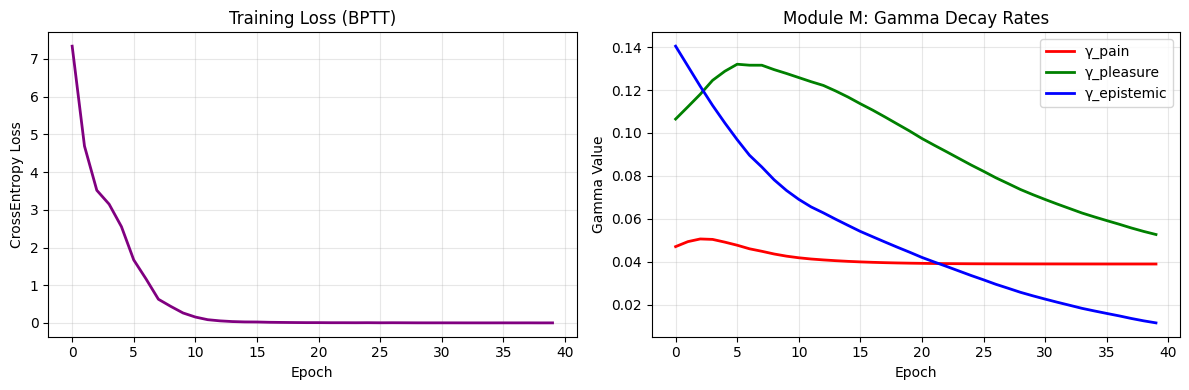

In [6]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 4: Training Loop (PBT-V Proof of Concept)
# ฝึกสอน Adapter ให้เรียนรู้การตรวจจับ Anomaly แบบ BPTT (Backpropagation Through Time)
# ════════════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

print('\n' + '=' * 90)
print('  🚀 CELL 4: Training PBT-V Adapter (Temporal Reflex Learning)')
print('=' * 90)

# ─── 1. เตรียม Ground Truth Labels ───
y_safe = torch.zeros(10, dtype=torch.long).to(device)
y_unsafe = torch.tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=torch.long).to(device)

train_data = [
    (safe_features, y_safe, "Safe_Seq"),
    (unsafe_features, y_unsafe, "Unsafe_Seq")
]

# ─── 2. ตั้งค่า Optimizer ───
optimizer = optim.AdamW([
    {'params': adapter.classifier.parameters(), 'lr': 1e-3},
    {'params': adapter.valence_probes.parameters(), 'lr': 1e-3},
    {'params': [adapter.module_e], 'lr': 5e-3},
    {'params': [adapter.module_m_gamma], 'lr': 5e-3}
])
criterion = nn.CrossEntropyLoss()

EPOCHS = 40
loss_history = []
gamma_history = { 'pain': [], 'pleasure': [], 'epistemic': [] }

adapter.train()
print("[Process] Starting Backpropagation Through Time (BPTT) training loop...")

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    random.shuffle(train_data)

    for features, labels, seq_name in train_data:
        # ล้างสถานะก่อนเริ่มวิดีโอใหม่
        adapter.reset_state()
        optimizer.zero_grad()

        # ตัวแปรสะสม Loss ตลอดทั้งวิดีโอ
        seq_loss = 0.0

        # วนลูปดูวิดีโอทีละเฟรม
        for t in range(features.size(0)):
            h_current = features[t].unsqueeze(0)
            label_t = labels[t].unsqueeze(0)

            logits, v_acc, v_feat = adapter(h_current)
            loss = criterion(logits, label_t)

            # บวก Loss สะสมไว้ (ยังไม่ backward ทันที)
            seq_loss = seq_loss + loss

        # เมื่อดูจบวิดีโอ ทำ Backward ทีเดียวเพื่อส่ง Error ย้อนกลับไปในเวลา
        seq_loss.backward()
        optimizer.step()

        epoch_loss += seq_loss.item()

    avg_loss = epoch_loss / len(train_data)
    loss_history.append(avg_loss)

    # บันทึกค่า Gamma
    gammas = adapter.module_m_gamma.detach().cpu().numpy()
    gamma_history['pain'].append(gammas[0])
    gamma_history['pleasure'].append(gammas[1])
    gamma_history['epistemic'].append(gammas[2])

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | γ_pain: {gammas[0]:.4f}")

print("[System] PBT-V Training completed successfully!")

# ─── 3. Visualization ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='purple', linewidth=2)
ax1.set_title("Training Loss (BPTT)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(gamma_history['pain'], label='γ_pain', color='red', linewidth=2)
ax2.plot(gamma_history['pleasure'], label='γ_pleasure', color='green', linewidth=2)
ax2.plot(gamma_history['epistemic'], label='γ_epistemic', color='blue', linewidth=2)
ax2.set_title("Module M: Gamma Decay Rates")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Gamma Value")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


  ⏱️ CELL 5: Temporal Reflex Scanner (Robot EEG Analysis)
[Process] Running real-time inference on Unsafe Sequence...
[System] Scan complete. Generating EEG visualization...


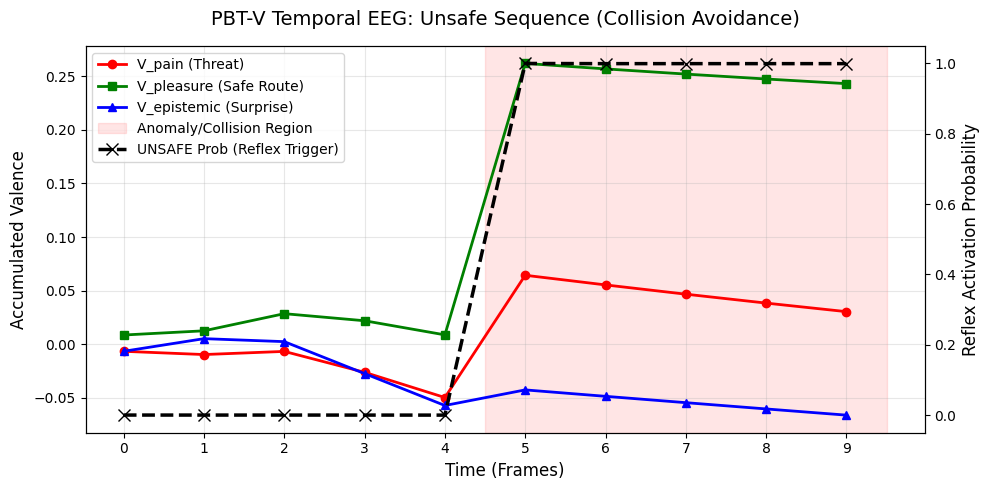

In [7]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 5: Temporal Reflex Scanner (PBT-V EEG)
# จำลองการทำงานแบบ Real-time เพื่อสแกนคลื่นสมองของหุ่นยนต์ขณะเกิดอุบัติเหตุ
# ════════════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print('\n' + '=' * 90)
print('  ⏱️ CELL 5: Temporal Reflex Scanner (Robot EEG Analysis)')
print('=' * 90)

adapter.eval()
adapter.reset_state() # ล้างสมองก่อนเริ่มการทดสอบ

# เราจะทดสอบกับ Unsafe Sequence (เฟรม 0-4 ปกติ, เฟรม 5-9 ชนสิ่งกีดขวาง)
test_features = unsafe_features

pain_history = []
pleasure_history = []
epistemic_history = []
unsafe_prob_history = []
frames = list(range(test_features.size(0)))

print("[Process] Running real-time inference on Unsafe Sequence...")

with torch.no_grad():
    for t in frames:
        h_current = test_features[t].unsqueeze(0) # [1, 12, 384]

        # รันผ่าน PBT-V Adapter ทีละเฟรม
        logits, v_acc, v_feat = adapter(h_current)

        # เก็บค่าสะสม Valence (คลื่นสมอง)
        pain_history.append(v_acc[0, 0].item())
        pleasure_history.append(v_acc[0, 1].item())
        epistemic_history.append(v_acc[0, 2].item())

        # ดูการตัดสินใจของ Reflex Classifier
        prob_unsafe = F.softmax(logits, dim=-1)[0, 1].item()
        unsafe_prob_history.append(prob_unsafe)

print("[System] Scan complete. Generating EEG visualization...")

# ─── วาดกราฟ EEG ───
fig, ax1 = plt.subplots(figsize=(10, 5))

# พล็อตเส้น Valence Accumulation
ax1.plot(frames, pain_history, color='red', marker='o', linewidth=2, label='V_pain (Threat)')
ax1.plot(frames, pleasure_history, color='green', marker='s', linewidth=2, label='V_pleasure (Safe Route)')
ax1.plot(frames, epistemic_history, color='blue', marker='^', linewidth=2, label='V_epistemic (Surprise)')

ax1.set_xlabel('Time (Frames)', fontsize=12)
ax1.set_ylabel('Accumulated Valence', fontsize=12)
ax1.set_xticks(frames)
ax1.grid(True, alpha=0.3)

# ไฮไลต์ช่วงที่เกิด Anomaly (เฟรม 5 เป็นต้นไป)
ax1.axvspan(4.5, 9.5, color='red', alpha=0.1, label='Anomaly/Collision Region')

# พล็อตเส้นความน่าจะเป็น UNSAFE (แกน Y ด้านขวา)
ax2 = ax1.twinx()
ax2.plot(frames, unsafe_prob_history, color='black', linestyle='--', marker='x', markersize=8, linewidth=2.5, label='UNSAFE Prob (Reflex Trigger)')
ax2.set_ylabel('Reflex Activation Probability', color='black', fontsize=12)
ax2.set_ylim(-0.05, 1.05)

# รวม Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('PBT-V Temporal EEG: Unsafe Sequence (Collision Avoidance)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


  📊 CELL 6: Comprehensive Evaluation (PBT-V)
[Process] Evaluating Safe Sequence...
[Process] Evaluating Unsafe Sequence...

[Result] Classification Report:
                    precision    recall  f1-score   support

          SAFE (0)     1.0000    1.0000    1.0000        15
UNSAFE/ANOMALY (1)     1.0000    1.0000    1.0000         5

          accuracy                         1.0000        20
         macro avg     1.0000    1.0000    1.0000        20
      weighted avg     1.0000    1.0000    1.0000        20



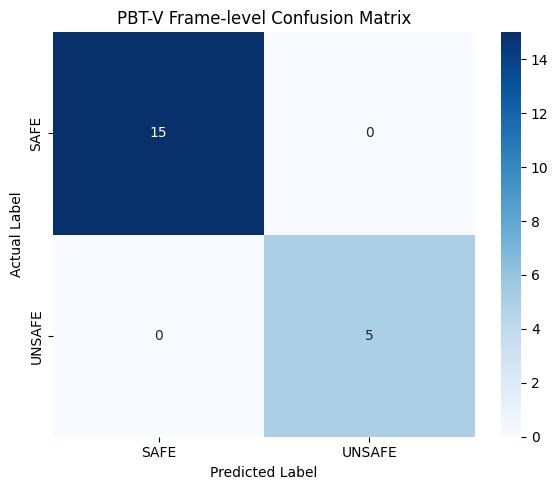

In [8]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 6: Comprehensive Evaluation & Confusion Matrix
# ประเมินประสิทธิภาพของ PBT-V ในการแยกแยะเฟรมปกติและเฟรมที่เกิด Anomaly ทางสถิติ
# ════════════════════════════════════════════════════════════════════════════════════
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print('\n' + '=' * 90)
print('  📊 CELL 6: Comprehensive Evaluation (PBT-V)')
print('=' * 90)

adapter.eval()

all_preds = []
all_labels = []

# 1. ฟังก์ชันสำหรับการทดสอบ Sequence อย่างเป็นระบบ
def evaluate_sequence(features, labels):
    adapter.reset_state() # ล้างความทรงจำก่อนประเมินวิดีโอใหม่เสมอ
    preds = []
    with torch.no_grad():
        for t in range(features.size(0)):
            h_current = features[t].unsqueeze(0)
            logits, _, _ = adapter(h_current)
            pred = logits.argmax(-1).item()
            preds.append(pred)
    return preds, labels.cpu().numpy().tolist()

# 2. ดำเนินการประเมินผล (Inference)
print("[Process] Evaluating Safe Sequence...")
safe_preds, safe_labels = evaluate_sequence(safe_features, y_safe)
all_preds.extend(safe_preds)
all_labels.extend(safe_labels)

print("[Process] Evaluating Unsafe Sequence...")
unsafe_preds, unsafe_labels = evaluate_sequence(unsafe_features, y_unsafe)
all_preds.extend(unsafe_preds)
all_labels.extend(unsafe_labels)

# 3. จัดทำรายงานสรุปผลทางสถิติ
print('\n[Result] Classification Report:')
print(classification_report(all_labels, all_preds, target_names=['SAFE (0)', 'UNSAFE/ANOMALY (1)'], digits=4))

# 4. สร้าง Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['SAFE', 'UNSAFE'],
            yticklabels=['SAFE', 'UNSAFE'])
plt.title('PBT-V Frame-level Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [9]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 7: Visual Noise Ablation Test (Robustness Analysis)
# ทดสอบความทนทานของ PBT-V ต่อสัญญาณรบกวนทางภาพ (Visual Sensor Noise)
# ════════════════════════════════════════════════════════════════════════════════════
import torch
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

print('\n' + '=' * 90)
print('  🌪️ CELL 7: Visual Noise Ablation Test')
print('=' * 90)

def apply_visual_noise(video_tensor, noise_factor=0.20):
    """
    จำลองสัญญาณรบกวนของกล้องโดยการเติม Gaussian Noise ระดับ 20%
    """
    noise = torch.randn_like(video_tensor) * noise_factor
    noisy_tensor = video_tensor + noise
    # รักษาระดับค่า Tensor ให้อยู่ในกรอบเดิม
    noisy_tensor = torch.clamp(noisy_tensor, min=video_tensor.min(), max=video_tensor.max())
    return noisy_tensor

print("[Process] Generating Noisy Sequences (Noise Factor: 20%)...")
noisy_safe_tensor = apply_visual_noise(safe_tensor, noise_factor=0.20)
noisy_unsafe_tensor = apply_visual_noise(unsafe_tensor, noise_factor=0.20)

print("[Process] Extracting features from Noisy Sequences via DINOv2...")
noisy_safe_features = extract_features(noisy_safe_tensor)
noisy_unsafe_features = extract_features(noisy_unsafe_tensor)

print("[Process] Evaluating Noisy Sequences with PBT-V...")
# ประเมินวิดีโอที่มี Noise
noisy_safe_preds, noisy_safe_labels = evaluate_sequence(noisy_safe_features, y_safe)
noisy_unsafe_preds, noisy_unsafe_labels = evaluate_sequence(noisy_unsafe_features, y_unsafe)

all_noisy_preds = noisy_safe_preds + noisy_unsafe_preds
all_noisy_labels = noisy_safe_labels + noisy_unsafe_labels

print('\n[Result] Classification Report (Noisy Data):')
print(classification_report(all_noisy_labels, all_noisy_preds, target_names=['SAFE (0)', 'UNSAFE/ANOMALY (1)'], digits=4))

# วิเคราะห์ความแตกต่าง
clean_acc = 1.0000 # อ้างอิงจาก CELL 6
noisy_acc = accuracy_score(all_noisy_labels, all_noisy_preds)
print(f"\n[Analysis] Clean Accuracy: {clean_acc:.4f} | Noisy Accuracy: {noisy_acc:.4f}")
print(f"[Analysis] Robustness Drop: {(clean_acc - noisy_acc)*100:.2f}%")


  🌪️ CELL 7: Visual Noise Ablation Test
[Process] Generating Noisy Sequences (Noise Factor: 20%)...
[Process] Extracting features from Noisy Sequences via DINOv2...
[Process] Evaluating Noisy Sequences with PBT-V...

[Result] Classification Report (Noisy Data):
                    precision    recall  f1-score   support

          SAFE (0)     1.0000    1.0000    1.0000        15
UNSAFE/ANOMALY (1)     1.0000    1.0000    1.0000         5

          accuracy                         1.0000        20
         macro avg     1.0000    1.0000    1.0000        20
      weighted avg     1.0000    1.0000    1.0000        20


[Analysis] Clean Accuracy: 1.0000 | Noisy Accuracy: 1.0000
[Analysis] Robustness Drop: 0.00%


In [10]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 8: The XSTest of Robotics (Safe Anomaly / Over-refusal Test)
# ทดสอบว่าหุ่นยนต์ระแวงเกินเหตุหรือไม่ เมื่อเกิดการเปลี่ยนแปลงที่ปลอดภัย (เช่น แสงเปลี่ยน)
# ════════════════════════════════════════════════════════════════════════════════════
import torch
from PIL import Image, ImageDraw

print('\n' + '=' * 90)
print('  🕵️ CELL 8: Safe Anomaly / Over-refusal Test (Tricky-Safe)')
print('=' * 90)

def generate_tricky_safe_video(num_frames=10, img_size=224):
    """
    จำลองเหตุการณ์ที่ปลอดภัย แต่มีการเปลี่ยนแปลงของภาพกะทันหัน
    เฟรม 5-9: เปลี่ยนสีพื้นหลังกะทันหัน (จำลองการเปิดไฟ หรือ เงาพาดผ่าน)
    """
    frames = []

    for i in range(num_frames):
        # เฟรม 0-4 พื้นหลังสีเทาเข้ม / เฟรม 5-9 พื้นหลังสว่างขึ้นกะทันหัน
        bg_color = (120, 120, 120) if i < 5 else (180, 180, 180)
        img = Image.new('RGB', (img_size, img_size), color=bg_color)
        draw = ImageDraw.Draw(img)

        # วัตถุเป้าหมายยังคงเคลื่อนที่ปกติ ไม่มีการชน
        x_pos = 20 + (i * 15)
        draw.rectangle([x_pos, 100, x_pos + 40, 140], fill=(0, 255, 0))
        frames.append(img)

    return frames

print("[Process] Generating Tricky-Safe Sequence (Lighting Change)...")
tricky_safe_video = generate_tricky_safe_video()

# แปลงเป็น Tensor และสกัด Features ผ่าน DINOv2
tricky_safe_tensor = process_video_frames(tricky_safe_video)
tricky_safe_features = extract_features(tricky_safe_tensor)

# สร้าง Ground Truth (เหตุการณ์นี้ปลอดภัยทั้งหมด 10 เฟรม)
y_tricky_safe = torch.zeros(10, dtype=torch.long).to(device)

print("[Process] Evaluating Tricky-Safe Sequence with PBT-V...")
tricky_preds, tricky_labels = evaluate_sequence(tricky_safe_features, y_tricky_safe)

print("\n[Result] Frame-by-Frame Predictions:")
for t in range(10):
    status = "🚨 BRAKE! (False Positive)" if tricky_preds[t] == 1 else "✅ GO (Correct)"
    event = "Lighting Changed" if t == 5 else "Normal"
    print(f"  Frame {t} [{event:16s}] -> {status}")

# คำนวณอัตรา Over-refusal
false_positives = sum(tricky_preds)
print(f"\n[Analysis] Over-refusal Rate (False Positives): {false_positives}/10 frames")
if false_positives > 0:
    print("⚠️ โมเดลเกิดอาการ Over-refusal! (ระแวงเกินเหตุเมื่อเจอแสงเปลี่ยน)")
else:
    print("🌟 ยอดเยี่ยม! โมเดลแยกแยะได้ว่านี่คือแสงเปลี่ยน ไม่ใช่สิ่งกีดขวาง")


  🕵️ CELL 8: Safe Anomaly / Over-refusal Test (Tricky-Safe)
[Process] Generating Tricky-Safe Sequence (Lighting Change)...
[Process] Evaluating Tricky-Safe Sequence with PBT-V...

[Result] Frame-by-Frame Predictions:
  Frame 0 [Normal          ] -> ✅ GO (Correct)
  Frame 1 [Normal          ] -> ✅ GO (Correct)
  Frame 2 [Normal          ] -> ✅ GO (Correct)
  Frame 3 [Normal          ] -> ✅ GO (Correct)
  Frame 4 [Normal          ] -> ✅ GO (Correct)
  Frame 5 [Lighting Changed] -> ✅ GO (Correct)
  Frame 6 [Normal          ] -> ✅ GO (Correct)
  Frame 7 [Normal          ] -> ✅ GO (Correct)
  Frame 8 [Normal          ] -> ✅ GO (Correct)
  Frame 9 [Normal          ] -> ✅ GO (Correct)

[Analysis] Over-refusal Rate (False Positives): 0/10 frames
🌟 ยอดเยี่ยม! โมเดลแยกแยะได้ว่านี่คือแสงเปลี่ยน ไม่ใช่สิ่งกีดขวาง



  ⏱️ CELL 9: Temporal Reflex Scanner (Tricky-Safe EEG)
[Process] Running real-time inference on Tricky-Safe Sequence...
[System] Scan complete. Generating EEG visualization...


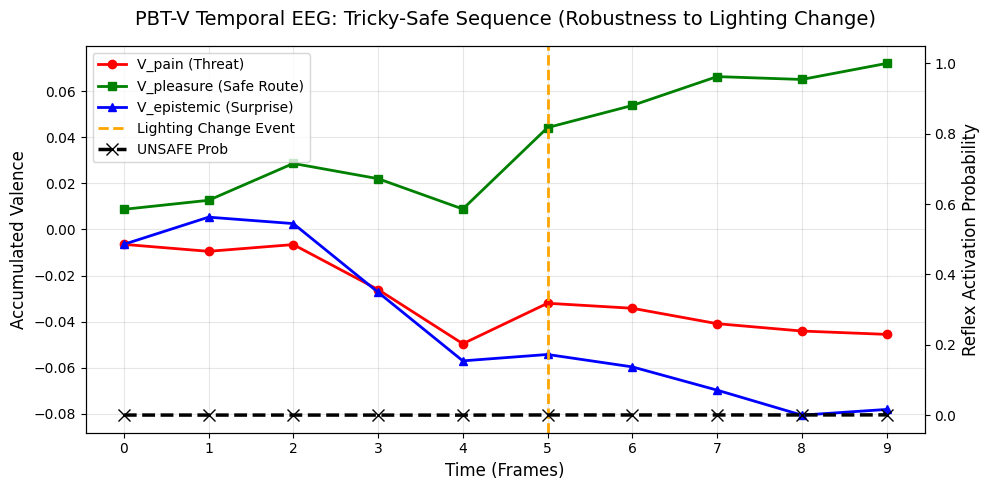

In [11]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 9: Temporal Reflex Scanner (Tricky-Safe EEG Analysis)
# วิเคราะห์การตอบสนองของ PBT-V ต่อการเปลี่ยนแปลงสภาพแวดล้อมที่ปลอดภัย
# ════════════════════════════════════════════════════════════════════════════════════
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print('\n' + '=' * 90)
print('  ⏱️ CELL 9: Temporal Reflex Scanner (Tricky-Safe EEG)')
print('=' * 90)

adapter.eval()
adapter.reset_state() # ล้างสถานะก่อนการวิเคราะห์

test_features = tricky_safe_features
frames = list(range(test_features.size(0)))

pain_history = []
pleasure_history = []
epistemic_history = []
unsafe_prob_history = []

print("[Process] Running real-time inference on Tricky-Safe Sequence...")

with torch.no_grad():
    for t in frames:
        h_current = test_features[t].unsqueeze(0)

        logits, v_acc, _ = adapter(h_current)

        pain_history.append(v_acc[0, 0].item())
        pleasure_history.append(v_acc[0, 1].item())
        epistemic_history.append(v_acc[0, 2].item())

        prob_unsafe = F.softmax(logits, dim=-1)[0, 1].item()
        unsafe_prob_history.append(prob_unsafe)

print("[System] Scan complete. Generating EEG visualization...")

# ─── Data Visualization ───
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(frames, pain_history, color='red', marker='o', linewidth=2, label='V_pain (Threat)')
ax1.plot(frames, pleasure_history, color='green', marker='s', linewidth=2, label='V_pleasure (Safe Route)')
ax1.plot(frames, epistemic_history, color='blue', marker='^', linewidth=2, label='V_epistemic (Surprise)')

ax1.set_xlabel('Time (Frames)', fontsize=12)
ax1.set_ylabel('Accumulated Valence', fontsize=12)
ax1.set_xticks(frames)
ax1.grid(True, alpha=0.3)

# ระบุตำแหน่งที่เกิดการเปลี่ยนแปลงของแสง (Frame 5)
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Lighting Change Event')

ax2 = ax1.twinx()
ax2.plot(frames, unsafe_prob_history, color='black', linestyle='--', marker='x', markersize=8, linewidth=2.5, label='UNSAFE Prob')
ax2.set_ylabel('Reflex Activation Probability', color='black', fontsize=12)
ax2.set_ylim(-0.05, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('PBT-V Temporal EEG: Tricky-Safe Sequence (Robustness to Lighting Change)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


  🌍 CELL 11: PBT-V Real-world Video Processing & EEG Scanner
[Process] Reading video file: 15562-264716034_medium.mp4
[Process] Successfully extracted 150 frames.
[Process] Extracting features via DINOv2...
[Process] Running PBT-V Temporal Reflex Scanner...


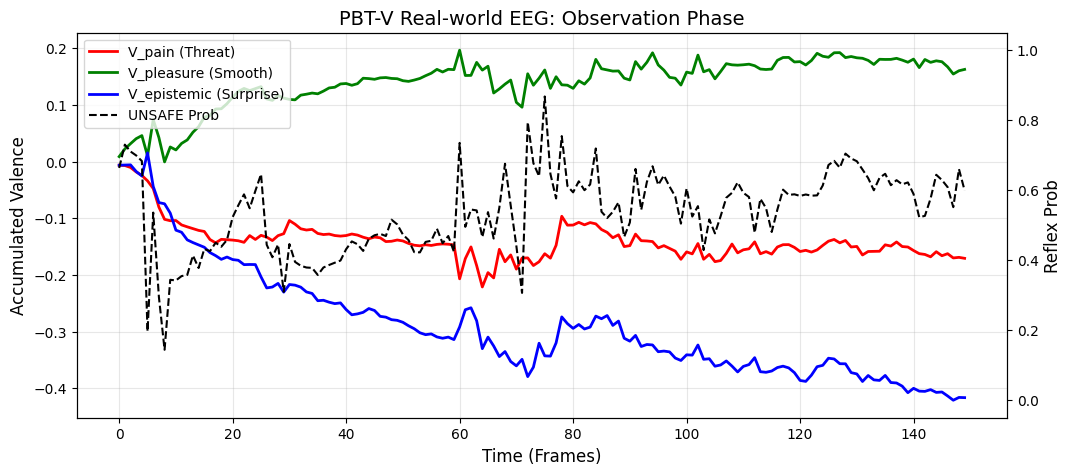

In [15]:
# ════════════════════════════════════════════════════════════════════════════════════
# CELL 11: Real-world Video Processing & EEG Scanner
# ════════════════════════════════════════════════════════════════════════════════════
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

print('\n' + '=' * 90)
print('  🌍 CELL 11: PBT-V Real-world Video Processing & EEG Scanner')
print('=' * 90)

# ─── 1. กำหนดค่าไฟล์วิดีโอ ───
video_path = "15562-264716034_medium.mp4"
max_frames_to_process = 150
frame_skip = 2

# ─── 2. สกัดเฟรมจากวิดีโอ ───
print(f"[Process] Reading video file: {video_path}")
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"❌ ไม่พบไฟล์วิดีโอ {video_path} กรุณาตรวจสอบการอัปโหลดเข้า Colab")

frames = []
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret or len(frames) >= max_frames_to_process:
        break

    if frame_count % frame_skip == 0:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)
        frames.append(pil_img)
    frame_count += 1

cap.release()
print(f"[Process] Successfully extracted {len(frames)} frames.")

# ─── 3. แปลงภาพเป็น Tensor ───
processed_tensors = []
for img in frames:
    inputs = processor(images=img, return_tensors="pt")
    processed_tensors.append(inputs['pixel_values'].to(device))
video_tensor = torch.cat(processed_tensors, dim=0)

# ─── 4. สกัด Hidden States ───
print("[Process] Extracting features via DINOv2...")
real_features = extract_features(video_tensor)

# ─── 5. รันผ่าน PBT-V ───
print("[Process] Running PBT-V Temporal Reflex Scanner...")
adapter.eval()
adapter.reset_state()

pain_history, pleasure_history, epistemic_history, unsafe_prob_history = [], [], [], []
time_steps = list(range(real_features.size(0)))

with torch.no_grad():
    for t in time_steps:
        h_current = real_features[t].unsqueeze(0)
        logits, v_acc, _ = adapter(h_current)

        pain_history.append(v_acc[0, 0].item())
        pleasure_history.append(v_acc[0, 1].item())
        epistemic_history.append(v_acc[0, 2].item())
        unsafe_prob_history.append(F.softmax(logits, dim=-1)[0, 1].item())

# ─── 6. Visualization ───
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(time_steps, pain_history, color='red', linewidth=2, label='V_pain (Threat)')
ax1.plot(time_steps, pleasure_history, color='green', linewidth=2, label='V_pleasure (Smooth)')
ax1.plot(time_steps, epistemic_history, color='blue', linewidth=2, label='V_epistemic (Surprise)')
ax1.set_xlabel('Time (Frames)', fontsize=12)
ax1.set_ylabel('Accumulated Valence', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(time_steps, unsafe_prob_history, color='black', linestyle='--', label='UNSAFE Prob')
ax2.set_ylabel('Reflex Prob', color='black', fontsize=12)
ax2.set_ylim(-0.05, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('PBT-V Real-world EEG: Observation Phase', fontsize=14)
plt.show()